## Setup the enviroment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
results_path = "/content/drive/MyDrive/deep learning/UPF_Deep_Learning_2026/Final Project/results"

In [ ]:
#if needed it
!pip install torchinfo

In [ ]:
import os
import time
import warnings
import random
from typing import Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchinfo import summary
import torch.optim as optim
import numpy as np
from torch.utils.data import random_split

### Dataset class for our data

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
from torchvision import transforms


class InfraredPersonDataset(Dataset):
    """
    PyTorch Dataset for infrared person detection classification.
    Uses the CSV file generated by process_dataset.py
    """

    def __init__(self, csv_path, images_dir, transform=None):
        """
        Args:
            csv_path (str): Path to the CSV file with annotations (dataset_labels.csv)
            images_dir (str): Directory with all the images
            transform (callable, optional): Optional transform to be applied on images
        """
        self.annotations = pd.read_csv(csv_path)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        # Get image filename and label
        img_name = self.annotations.iloc[idx, 0]  # 'filename' column
        label = self.annotations.iloc[idx, 1]     # 'label' column

        # Load image
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('L')  # Convert grayscale

        # Apply transforms if any
        if self.transform:
            image = self.transform(image)

        return image, label


def get_default_transforms(train=True):
    """
    Transforms for training/validation.
    Resize handles both native resolutions (1280×1024 and 640×512) uniformly.
    """
    if train:
        return transforms.Compose([
            transforms.Resize((224, 224)),  # accepts both 1280×1024 and 640×512
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5],
                                 std=[0.5]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5],
                                 std=[0.5]),
        ])

## Handmade baseline

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

class SimpleInfraredCNN(nn.Module):
    def __init__(self):
        super(SimpleInfraredCNN, self).__init__()
        # Convolutional layers
        # Changed input channels from 3 to 1 for single-channel infrared images
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # After 3 rounds of 2x2 pooling, 224x224 becomes 28x28
        self.fc1 = nn.Linear(64 * 28 * 28, 128) # ((64 * 28 * 28) + 1) * 128 = 6.422.656
        self.fc2 = nn.Linear(128, 1)  # Binary classification # 128+1 = 129
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cuda', save_path=None):
    model.to(device)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    train_f1s = []
    val_f1s = []

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        train_loss, train_preds, train_targets = 0.0, [], []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            train_preds.extend((outputs > 0.5).cpu().numpy())
            train_targets.extend(labels.cpu().numpy())

        # Validation Phase
        model.eval()
        val_loss, val_preds, val_targets = 0.0, [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_preds.extend((outputs > 0.5).cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        # Metrics Calculation
        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_train_acc = (np.array(train_preds) == np.array(train_targets)).mean()
        epoch_val_acc = (np.array(val_preds) == np.array(val_targets)).mean()
        epoch_train_f1 = f1_score(train_targets, train_preds)
        epoch_val_f1 = f1_score(val_targets, val_preds)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)
        train_f1s.append(epoch_train_f1)
        val_f1s.append(epoch_val_f1)

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | F1: {epoch_train_f1:.4f}')
        print(f'Val Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | F1: {epoch_val_f1:.4f}')
        print('-' * 30)

    # Save the model at the end
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        # Saving the entire model as requested
        torch.save(model, save_path)
        print(f"Model saved to {save_path}")

    return train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s

In [ ]:
import os
import random
import zipfile
import torch

# Automatically find the CSV inside the ZIP
zip_path = "/content/drive/MyDrive/deep learning/UPF_Deep_Learning_2026/Final Project/data/dataset_LLVIP/results.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    # Look for the csv file automatically
    csv_files = [f for f in all_files if f.endswith('dataset_labels.csv')]
    if not csv_files:
        raise FileNotFoundError("Could not find dataset_labels.csv inside the ZIP.")

    INTERNAL_CSV_PATH = csv_files[0]
    # Assume images are in a folder called 'images' in the same parent directory as the CSV
    INTERNAL_IMAGES_DIR = os.path.join(os.path.dirname(os.path.dirname(INTERNAL_CSV_PATH)), "images")

print(f"Found CSV at: {INTERNAL_CSV_PATH}")
print(f"Assuming images at: {INTERNAL_IMAGES_DIR}")



Found CSV at: results/labels/dataset_labels.csv
Assuming images at: results/images


In [ ]:
# Faster Pre-extraction
import zipfile
import os
import numpy as np

# Hyperparameters
BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LR          = 0.001
VAL_SPLIT   = 0.2
SEED        = 42

torch.manual_seed(SEED)
random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Local directory for fast access
local_extract_path = "/content/extracted_images"

if not os.path.exists(local_extract_path):
    print(f"Extracting data to /content/ for faster training...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        # We need both the images and the CSV labels
        members_to_extract = [m for m in z.namelist() if m.startswith(INTERNAL_IMAGES_DIR) or m == INTERNAL_CSV_PATH]
        z.extractall(path="/content/", members=members_to_extract)
    print("Extraction complete.")

# Switch to the faster Dataset that reads from disk instead of ZIP
full_dataset_fast = InfraredPersonDataset(
    csv_path=os.path.join("/content/", INTERNAL_CSV_PATH),
    images_dir=os.path.join("/content/", INTERNAL_IMAGES_DIR),
    transform=get_default_transforms(train=True)
)

# Calculate indices for the split
dataset_size = len(full_dataset_fast)
indices = list(range(dataset_size))
val_split_count = int(np.floor(VAL_SPLIT * dataset_size))

np.random.seed(SEED)
np.random.shuffle(indices)
#split train/val
train_idx, val_idx = indices[val_split_count:], indices[:val_split_count]

# Re-create subsets and loaders with the fast dataset
train_dataset = Subset(full_dataset_fast, train_idx)
val_ds_no_aug = InfraredPersonDataset(
    csv_path=os.path.join("/content/", INTERNAL_CSV_PATH),
    images_dir=os.path.join("/content/", INTERNAL_IMAGES_DIR),
    transform=get_default_transforms(train=False)
)
val_dataset = Subset(val_ds_no_aug, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

# Model, Optimizer (SGD with Momentum), Loss
model = SimpleInfraredCNN()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
criterion = nn.BCELoss()

# Start Training and Save entire model as .pkt
print("Start training...")
model_save_file = os.path.join(results_path, "handmade_monochannel.pkt")
train_loss, val_loss, train_accs, val_accs, train_f1, val_f1 = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS, device=device, save_path=model_save_file)


Device: cuda
Extracting data to /content/ for faster training...
Extraction complete.
Start training...
Epoch 1/10
Train Loss: 0.6261 | Acc: 0.6334 | F1: 0.7378
Val Loss: 0.5504 | Acc: 0.6733 | F1: 0.7727
------------------------------
Epoch 2/10
Train Loss: 0.4745 | Acc: 0.7708 | F1: 0.8045
Val Loss: 0.3658 | Acc: 0.8451 | F1: 0.8704
------------------------------
Epoch 3/10
Train Loss: 0.3506 | Acc: 0.8499 | F1: 0.8700
Val Loss: 0.2824 | Acc: 0.8823 | F1: 0.9045
------------------------------
Epoch 4/10
Train Loss: 0.2684 | Acc: 0.8935 | F1: 0.9079
Val Loss: 0.2148 | Acc: 0.9204 | F1: 0.9331
------------------------------
Epoch 5/10
Train Loss: 0.2174 | Acc: 0.9147 | F1: 0.9261
Val Loss: 0.1715 | Acc: 0.9415 | F1: 0.9503
------------------------------
Epoch 6/10
Train Loss: 0.1834 | Acc: 0.9295 | F1: 0.9389
Val Loss: 0.1507 | Acc: 0.9503 | F1: 0.9582
------------------------------
Epoch 7/10
Train Loss: 0.1571 | Acc: 0.9418 | F1: 0.9497
Val Loss: 0.1145 | Acc: 0.9603 | F1: 0.9666
---

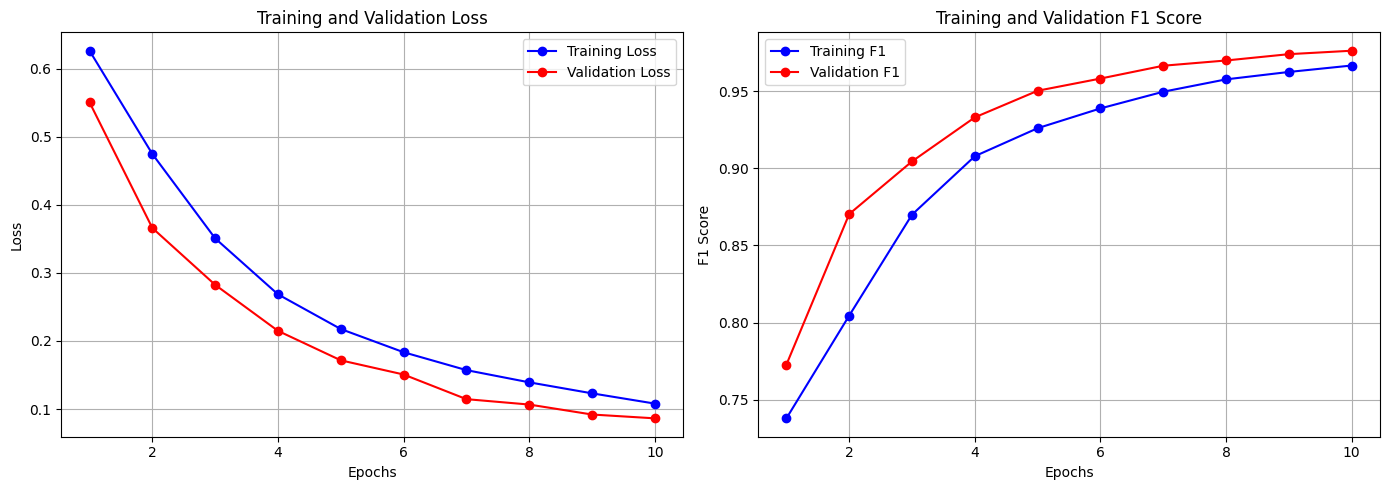

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Plot Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot F1 Score Curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_f1, 'b-o', label='Training F1')
plt.plot(epochs, val_f1, 'r-o', label='Validation F1')
plt.title('Training and Validation F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

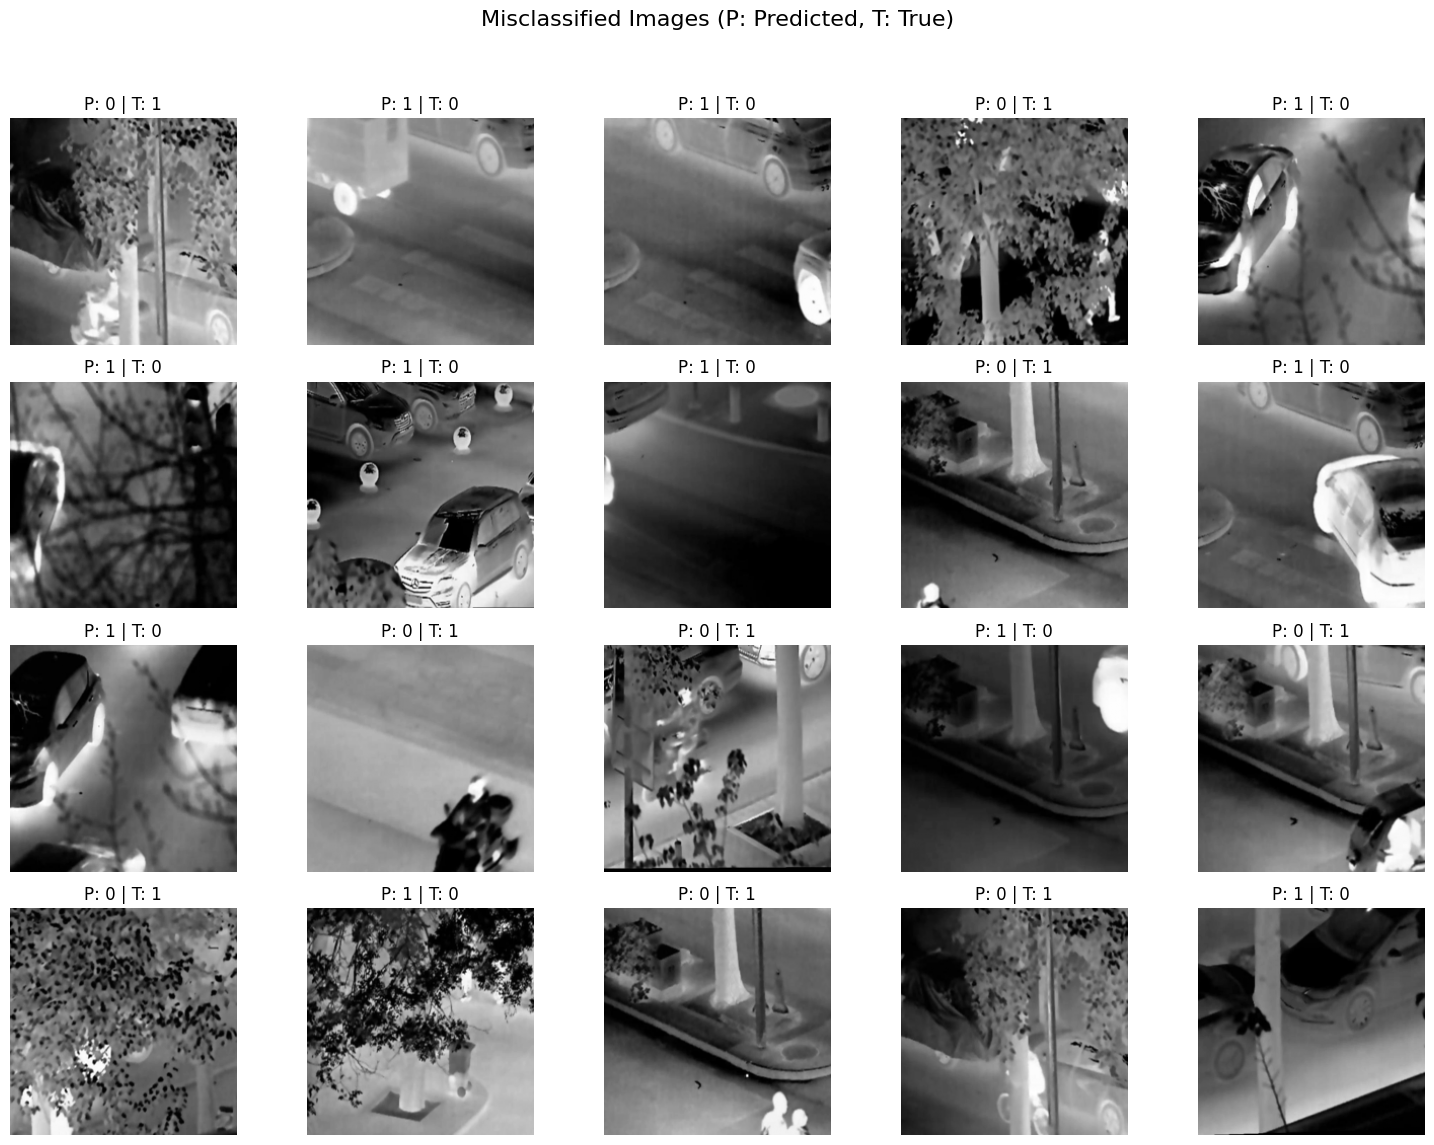

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_misclassified_images(model, loader, device, num_images=20):
    model.eval()
    misclassified = []

    # Iterate through validation set to find errors
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = (outputs > 0.5).float().cpu().view(-1)
            labels = labels.cpu().float()

            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    # Store image, predicted label, and true label
                    misclassified.append((inputs[i].cpu(), preds[i].item(), labels[i].item()))

                if len(misclassified) >= num_images:
                    break
            if len(misclassified) >= num_images:
                break

    # Plotting the results
    plt.figure(figsize=(15, 12))
    for i in range(len(misclassified)):
        img, pred, true = misclassified[i]
        # Undo normalization for visualization (assuming mean=0.5, std=0.5)
        img = img * 0.5 + 0.5
        img = img.squeeze().numpy() # Remove channel dim for grayscale plot

        plt.subplot(4, 5, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"P: {int(pred)} | T: {int(true)}")
        plt.axis('off')

    plt.suptitle("Misclassified Images (P: Predicted, T: True)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the function
plot_misclassified_images(model, val_loader, device, num_images=20)

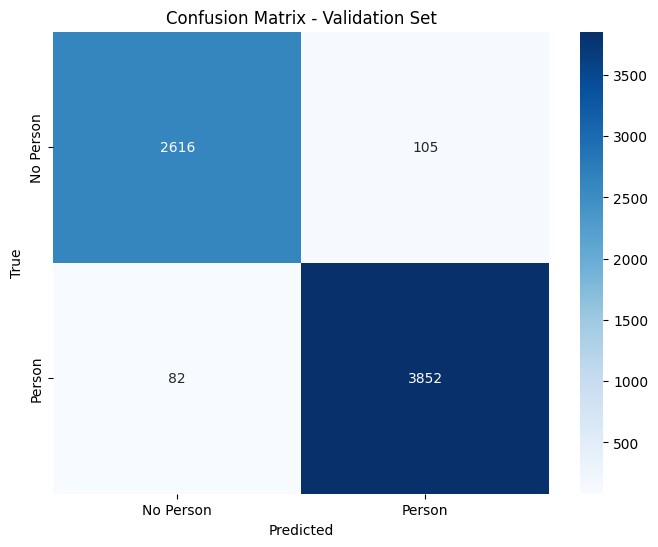

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_val_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = (outputs > 0.5).float().cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Person', 'Person'],
                yticklabels=['No Person', 'Person'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Validation Set')
    plt.show()

# Execute the plotting function
plot_val_confusion_matrix(model, val_loader, device)

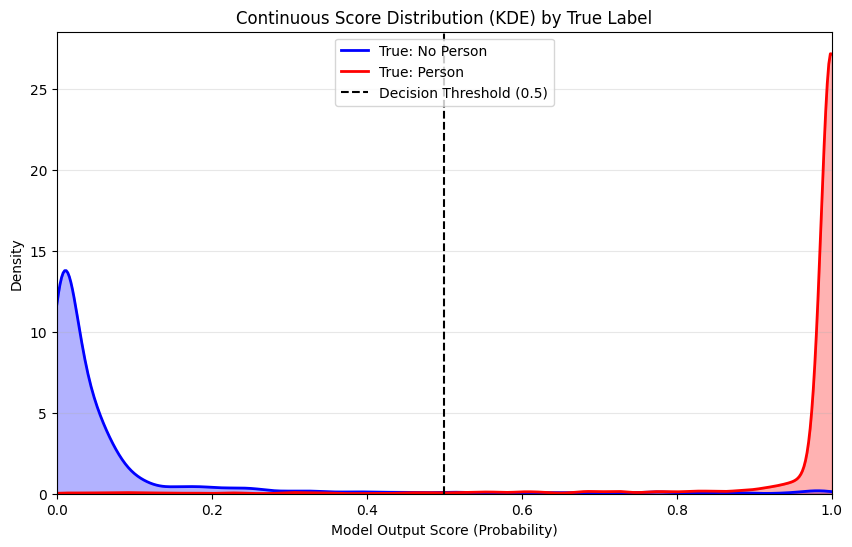

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from scipy.stats import gaussian_kde

def plot_score_distribution_continuous(model, loader, device):
    model.eval()
    scores_pos = []
    scores_neg = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu().numpy().flatten()
            labels = labels.cpu().numpy().flatten()

            for score, label in zip(outputs, labels):
                if label == 1:
                    scores_pos.append(score)
                else:
                    scores_neg.append(score)

    plt.figure(figsize=(10, 6))
    x_range = np.linspace(0, 1, 500)

    # Generate KDE for 'No Person'
    if len(scores_neg) > 1:
        kde_neg = gaussian_kde(scores_neg, bw_method=0.1)
        y_neg = kde_neg(x_range)
        plt.plot(x_range, y_neg, color='blue', lw=2, label='True: No Person')
        plt.fill_between(x_range, 0, y_neg, color='blue', alpha=0.3)

    # Generate KDE for 'Person'
    if len(scores_pos) > 1:
        kde_pos = gaussian_kde(scores_pos, bw_method=0.1)
        y_pos = kde_pos(x_range)
        plt.plot(x_range, y_pos, color='red', lw=2, label='True: Person')
        plt.fill_between(x_range, 0, y_pos, color='red', alpha=0.3)

    # Scale set back to linear (default)
    plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
    plt.xlabel('Model Output Score (Probability)')
    plt.ylabel('Density')
    plt.title('Continuous Score Distribution (KDE) by True Label')
    plt.legend(loc='upper center')
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(bottom=0)
    plt.show()

# Plot the distribution
plot_score_distribution_continuous(model, val_loader, device)

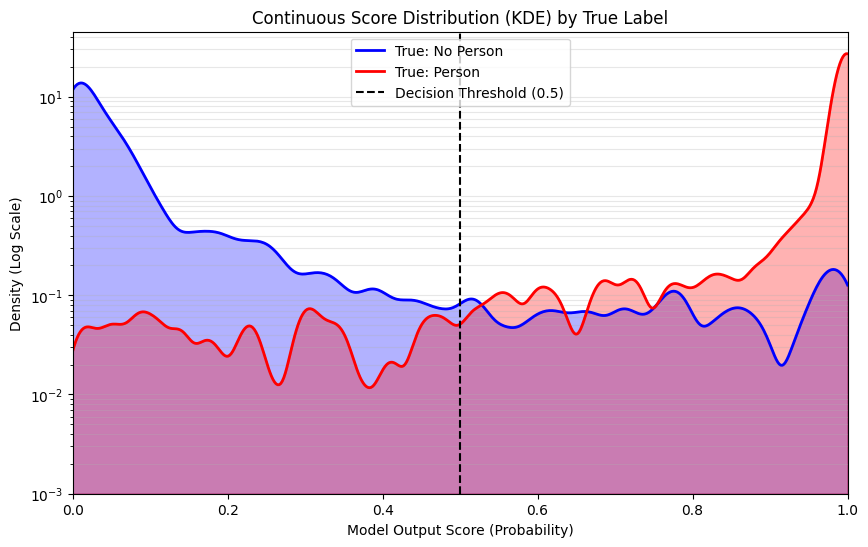

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from scipy.stats import gaussian_kde

def plot_score_distribution_continuous_log(model, loader, device):
    model.eval()
    scores_pos = []
    scores_neg = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu().numpy().flatten()
            labels = labels.cpu().numpy().flatten()

            for score, label in zip(outputs, labels):
                if label == 1:
                    scores_pos.append(score)
                else:
                    scores_neg.append(score)

    plt.figure(figsize=(10, 6))
    x_range = np.linspace(0, 1, 500)

    # Generate KDE for 'No Person'
    if len(scores_neg) > 1:
        kde_neg = gaussian_kde(scores_neg, bw_method=0.1)
        y_neg = kde_neg(x_range)
        plt.plot(x_range, y_neg, color='blue', lw=2, label='True: No Person')
        plt.fill_between(x_range, 1e-3, y_neg, color='blue', alpha=0.3)

    # Generate KDE for 'Person'
    if len(scores_pos) > 1:
        kde_pos = gaussian_kde(scores_pos, bw_method=0.1)
        y_pos = kde_pos(x_range)
        plt.plot(x_range, y_pos, color='red', lw=2, label='True: Person')
        plt.fill_between(x_range, 1e-3, y_pos, color='red', alpha=0.3)

    plt.yscale('log')
    plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
    plt.xlabel('Model Output Score (Probability)')
    plt.ylabel('Density (Log Scale)')
    plt.title('Continuous Score Distribution (KDE) by True Label')
    plt.legend(loc='upper center')
    plt.grid(axis='y', which='both', alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(bottom=1e-3) # Set floor for log scale visibility
    plt.show()

# Plot the distribution
plot_score_distribution_continuous_log(model, val_loader, device)